In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv(r"C:\Users\user\my_snippet\DataSets\coffee_shop.csv")
df.head()
df['revenue'] = df['unit_price'] * df['transaction_qty']
df['datetime'] = pd.to_datetime(df['transaction_date']+ ' ' +df['transaction_time'], format='%d-%m-%Y %H:%M:%S')
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.to_period("M")
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,revenue,datetime,hour,month
0,1,01-01-2023,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,6.0,2023-01-01 07:06:11,7,2023-01
1,2,01-01-2023,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01-01 07:08:56,7,2023-01
2,3,01-01-2023,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,9.0,2023-01-01 07:14:04,7,2023-01
3,4,01-01-2023,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2.0,2023-01-01 07:20:24,7,2023-01
4,5,01-01-2023,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,6.2,2023-01-01 07:22:41,7,2023-01


In [3]:
#Which product categories have the highest repeat transaction frequency
df.groupby('product_category')['transaction_qty'].sum().sort_values(ascending=False).reset_index()

,product_category,transaction_qty
0,Coffee,89250
1,Tea,69737
2,Bakery,23214
3,Drinking Chocolate,17457
4,Flavours,10511
5,Coffee beans,1828
6,Loose Tea,1210
7,Branded,776
8,Packaged Chocolate,487


In [4]:
#premium product status
high_price = df['unit_price'].quantile(0.90)
g = df.groupby(['product_detail','unit_price'])['revenue'].sum().reset_index()

# g[g['unit_price'] >= high_price].groupby('product_detail')['revenue'].sum()\
#                                 .plot(xlabel='Product Detail',
#                                       ylabel='Revenue',title='Premium Products Revenue Earning',
#                                       kind='bar')

In [ ]:
#store-wise demand
g = df.groupby(['store_location','product_category'])['transaction_qty'].sum().reset_index()
g.sort_values(['store_location','transaction_qty'],
              ascending=[True,False])
g.groupby('store_location').head()

,store_location,product_category,transaction_qty
0,Astoria,Bakery,7496
1,Astoria,Branded,279
2,Astoria,Coffee,29655
3,Astoria,Coffee beans,502
4,Astoria,Drinking Chocolate,6351
9,Hell's Kitchen,Bakery,7678
10,Hell's Kitchen,Branded,119
11,Hell's Kitchen,Coffee,30220
12,Hell's Kitchen,Coffee beans,790
13,Hell's Kitchen,Drinking Chocolate,5672


In [6]:
g.loc[
    g.groupby('store_location')['transaction_qty'].idxmax()
]

,store_location,product_category,transaction_qty
2,Astoria,Coffee,29655
11,Hell's Kitchen,Coffee,30220
20,Lower Manhattan,Coffee,29375


In [3]:
df.groupby('product_category')['transaction_id'] \
  .nunique()\
  .sort_values(ascending=False)

product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: transaction_id, dtype: int64

In [4]:
#low sales hour
df.groupby(['hour','product_category'])['transaction_qty'].sum().sort_values()

hour  product_category  
20    Loose Tea                 2
      Branded                   4
      Packaged Chocolate        7
      Coffee beans              9
18    Packaged Chocolate       10
                            ...  
9     Tea                    8139
10    Tea                    8152
8     Coffee                10145
9     Coffee                10221
10    Coffee                10898
Name: transaction_qty, Length: 135, dtype: int64

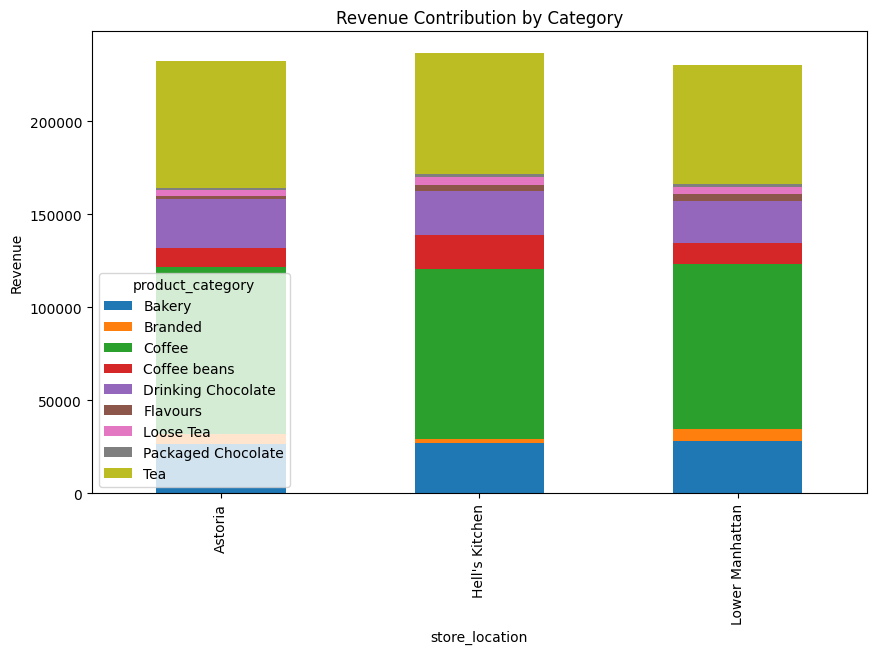

In [12]:
g = df.groupby(['store_location','product_category'])['revenue'] \
      .sum() \
      .unstack(fill_value=0)

g.plot(kind='bar', stacked=True, figsize=(10,6))

plt.ylabel('Revenue')
plt.title('Revenue Contribution by Category')
plt.show()